# ODIM_H5

In [1]:
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Download

Fetching ODIM_H5 radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename = DATASETS.fetch("71_20181220_060628.pvol.h5")

## xr.open_dataset

Making use of the xarray `odim` backend. We also need to provide the group. We use CfRadial2 group access pattern.

In [3]:
ds = xr.open_dataset(filename, group="sweep_0", engine="odim")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 40MB
Dimensions:            (azimuth: 360, range: 1200)
Coordinates:
  * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
    elevation          (azimuth) float64 3kB ...
    time               (azimuth) datetime64[ns] 3kB ...
  * range              (range) float32 5kB 125.0 375.0 ... 2.996e+05 2.999e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/18)
    DBZH               (azimuth, range) float64 3MB ...
    DBZH_CLEAN         (azimuth, range) float64 3MB ...
    VRADDH             (azimuth, range) float64 3MB ...
    VRADH              (azimuth, range) float64 3MB ...
    WRADH              (azimuth, range) float64 3MB ...
    TH                 (azimuth, range) float64 3MB ...
    ...                 ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    nyquist_velocity   float64 8B ...
Attributes:
    Conventions:  ODIM_H5/V2_2

In [4]:
ds.sweep_fixed_angle.values

array(0.5)

### Plot Time vs. Azimuth

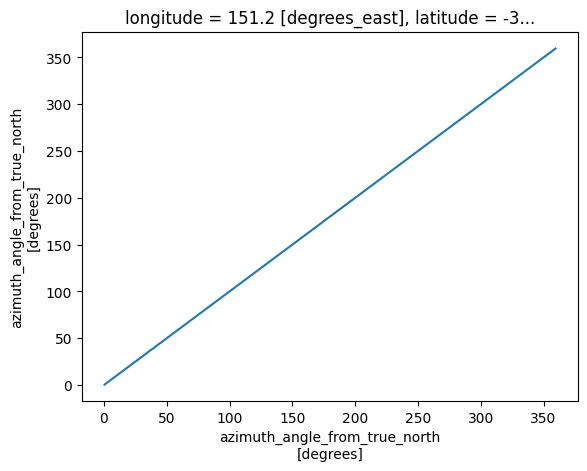

In [5]:
ds.azimuth.plot()

### Plot Range vs. Time

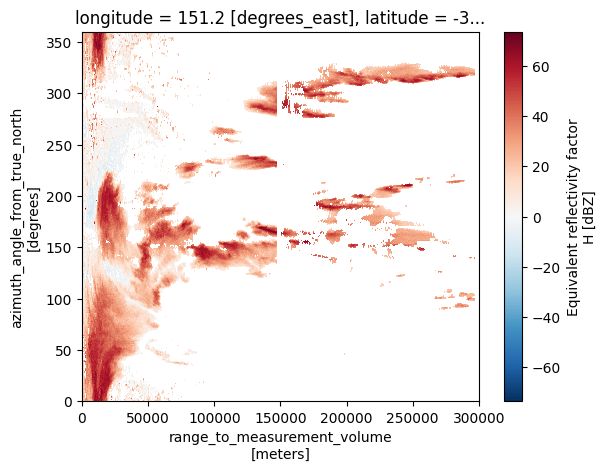

In [6]:
ds.DBZH.plot()

### Plot Range vs. Azimuth

We need to sort by azimuth and specify the y-coordinate.

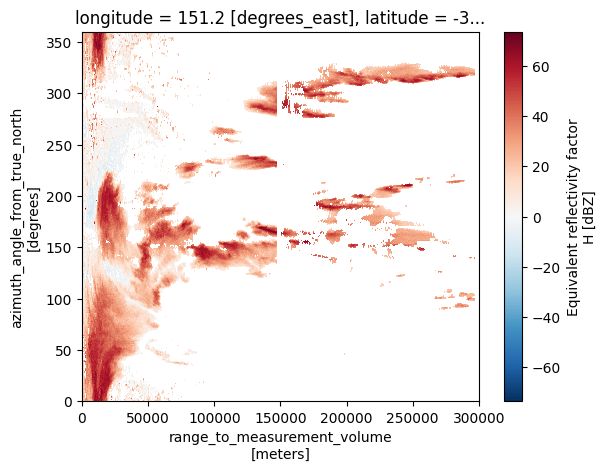

In [7]:
ds.DBZH.sortby("azimuth").plot(y="azimuth")

## backend_kwargs

Beside `first_dim` there are several additional backend_kwargs for the odim backend, which handle different aspects of angle alignment. This comes into play, when azimuth and/or elevation arrays are not evenly spacend and other issues.

In [8]:
?xd.io.OdimBackendEntrypoint

In [9]:
ds = xr.open_dataset(filename, group="sweep_0", engine="odim", first_dim="time")
display(ds)

<xarray.Dataset> Size: 40MB
Dimensions:            (time: 360, range: 1200)
Coordinates:
    azimuth            (time) float32 1kB ...
    elevation          (time) float64 3kB ...
  * time               (time) datetime64[ns] 3kB 2018-12-20T06:06:28.04027776...
  * range              (range) float32 5kB 125.0 375.0 ... 2.996e+05 2.999e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/18)
    DBZH               (time, range) float64 3MB ...
    DBZH_CLEAN         (time, range) float64 3MB ...
    VRADDH             (time, range) float64 3MB ...
    VRADH              (time, range) float64 3MB ...
    WRADH              (time, range) float64 3MB ...
    TH                 (time, range) float64 3MB ...
    ...                 ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    nyquist_velocity   float64 8B ...
Attributes:
    Conventions:  ODIM_H5/V2_2

## open_odim_datatree

The same works analoguous with the datatree loader. But additionally we can provide a sweep string, number or list.

In [10]:
?xd.io.open_odim_datatree

In [11]:
dtree = xd.io.open_odim_datatree(filename, sweep=8)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2018-12-20T06:09:21Z'
│       time_coverage_end    <U20 80B '2018-12-20T06:09:34Z'
│       longitude            float64 8B 151.2
│       altitude             float64 8B 195.0
│       latitude             float64 8B -33.7
│       sweep_group_name     (sweep) int64 8B 8
│       sweep_fixed_angle    (sweep) float64 8B 7.4
│   Attributes:
│       Conventions:      ODIM_H5/V2_2
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 590)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-12-20T06:09:30.39167...
│         * range              (range) float32 2kB 125.0 375.0 ... 1.471e+05 1.474e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float64 2MB ...
│           DBZH_CLEAN         (azimuth, range) float64 2MB ...
│           VRADDH             (azimuth, range) float64 2MB ...
│           VRADH              (azimuth, range) float64 2MB ...
│           WRADH              (azimuth, range) float64 2MB ...
│           TH                 (azimuth, range) float64 2MB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
└── Group: /radar_calibration

### Plot Sweep Range vs. Time

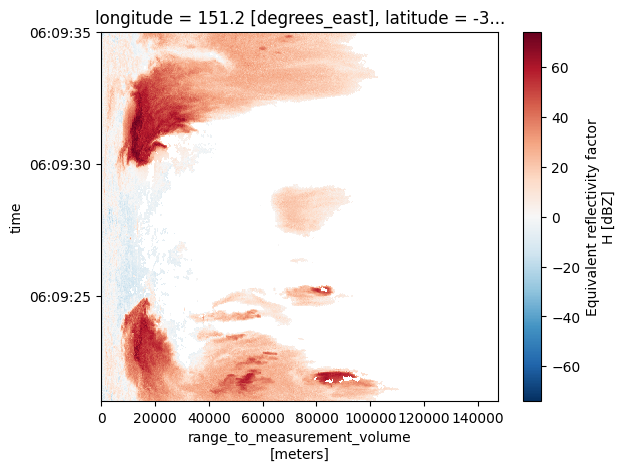

In [12]:
dtree["sweep_0"].ds.DBZH.sortby("time").plot(y="time")

### Plot Sweep Range vs. Azimuth

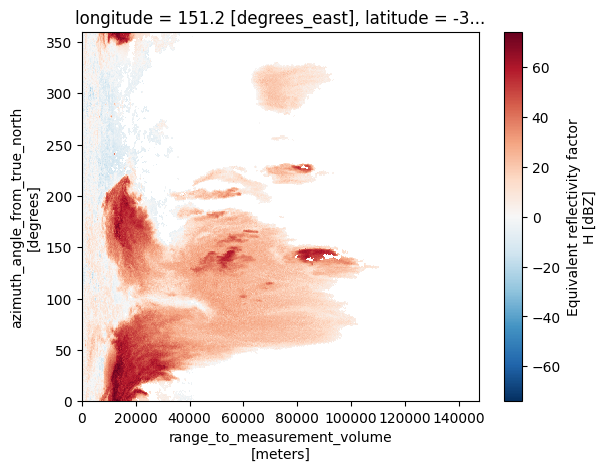

In [13]:
dtree["sweep_0"].ds.DBZH.plot()

In [14]:
dtree = xd.io.open_odim_datatree(filename, sweep="sweep_8")
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2018-12-20T06:09:21Z'
│       time_coverage_end    <U20 80B '2018-12-20T06:09:34Z'
│       longitude            float64 8B 151.2
│       altitude             float64 8B 195.0
│       latitude             float64 8B -33.7
│       sweep_group_name     (sweep) int64 8B 8
│       sweep_fixed_angle    (sweep) float64 8B 7.4
│   Attributes:
│       Conventions:      ODIM_H5/V2_2
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 590)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-12-20T06:09:30.39167...
│         * range              (range) float32 2kB 125.0 375.0 ... 1.471e+05 1.474e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float64 2MB ...
│           DBZH_CLEAN         (azimuth, range) float64 2MB ...
│           VRADDH             (azimuth, range) float64 2MB ...
│           VRADH              (azimuth, range) float64 2MB ...
│           WRADH              (azimuth, range) float64 2MB ...
│           TH                 (azimuth, range) float64 2MB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
└── Group: /radar_calibration

In [15]:
dtree = xd.io.open_odim_datatree(filename, sweep=[0, 1, 8])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 3)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2018-12-20T06:06:59Z'
│       time_coverage_end    <U20 80B '2018-12-20T06:09:48Z'
│       longitude            float64 8B 151.2
│       altitude             float64 8B 195.0
│       latitude             float64 8B -33.7
│       sweep_group_name     (sweep) int64 24B 1 2 9
│       sweep_fixed_angle    (sweep) float64 24B 0.9 1.3 10.0
│   Attributes:
│       Conventions:      ODIM_H5/V2_2
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 1200)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-12-20T06:07:19.82358...
│         * range              (range) float32 5kB 125.0 375.0 ... 2.996e+05 2.999e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBZH_CLEAN         (azimuth, range) float64 3MB ...
│           VRADDH             (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           TH                 (azimuth, range) float64 3MB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 360, range: 1200)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-12-20T06:07:42.68472...
│         * range              (range) float32 5kB 125.0 375.0 ... 2.996e+05 2.999e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBZH_CLEAN         (azimuth, range) float64 3MB ...
│           VRADDH             (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           TH                 (azimuth, range) float64 3MB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 360, range: 480)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-12-20T06:09:43.54582...
│         * range              (range) float32 2kB 125.0 375.0 ... 1.196e+05 1.199e+05
│           longitude          float64 8B ...
│           latitude      

In [16]:
dtree = xd.io.open_odim_datatree(filename, sweep=["sweep_0", "sweep_1", "sweep_8"])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 3)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2018-12-20T06:06:28Z'
│       time_coverage_end    <U20 80B '2018-12-20T06:09:34Z'
│       longitude            float64 8B 151.2
│       altitude             float64 8B 195.0
│       latitude             float64 8B -33.7
│       sweep_group_name     (sweep) int64 24B 0 1 8
│       sweep_fixed_angle    (sweep) float64 24B 0.5 0.9 7.4
│   Attributes:
│       Conventions:      ODIM_H5/V2_2
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 1200)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-12-20T06:06:50.11246...
│         * range              (range) float32 5kB 125.0 375.0 ... 2.996e+05 2.999e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBZH_CLEAN         (azimuth, range) float64 3MB ...
│           VRADDH             (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           TH                 (azimuth, range) float64 3MB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 360, range: 1200)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-12-20T06:07:19.82358...
│         * range              (range) float32 5kB 125.0 375.0 ... 2.996e+05 2.999e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBZH_CLEAN         (azimuth, range) float64 3MB ...
│           VRADDH             (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           TH                 (azimuth, range) float64 3MB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 360, range: 590)
│       Coordinates:
│         * azimuth            (azimuth) float32 1kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-12-20T06:09:30.39167...
│         * range              (range) float32 2kB 125.0 375.0 ... 1.471e+05 1.474e+05
│           longitude          float64 8B ...
│           latitude       